In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sqlalchemy import text
import os

# Configuring visual defaults
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['font.size'] = 10

# Move to project root 
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
print("Working directory:", os.getcwd())

load_dotenv() 

## Database Connection
DB_USER = os.getenv("DB_USER")
DB_PASS = os.getenv("DB_PASS")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

engine =create_engine(f"postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

with engine.connect() as conn:
    result = conn.execute(text("select count(*) from fraud_dw.fact_transactions"))
    count = result.scalar()
    print(f"Connected to database. Fact_transactions has {count:,} rows.")


Working directory: d:\Innomatics\Git_Uploads\Credit-card-risk-analytics
Connected to database. Fact_transactions has 590,540 rows.


In [5]:
query1 = """
select
		transaction_id,
		card_id,
		transaction_dt,
		is_fraud,
		transaction_amt,

		count(*) over (partition by card_id
						order by transaction_dt
						range between interval '1 hour' preceding and current row)
						as txns_last_1hr,

		count(*) over (partition by card_id
						order by transaction_dt
						range between interval '24 hour' preceding and current row)
						as txns_last_24hr,

		count(*) over (partition by card_id
						order by transaction_dt
						range between interval '7 days' preceding and current row)
						as txns_last_7d
from fraud_dw.fact_transactions
order by random() limit 50000;"""

df1 = pd.read_sql(query1,engine)
df1.sample(5)

,transaction_id,card_id,transaction_dt,is_fraud,transaction_amt,txns_last_1hr,txns_last_24hr,txns_last_7d
6588,3430987,1003,2018-04-10 17:38:07,False,30.95,4,29,284
39780,3146448,10995,2018-01-08 19:29:27,False,75.00,5,29,235
25646,3004845,4687,2017-12-06 15:23:11,False,500.00,1,10,39
45880,3218305,7978,2018-02-02 14:10:41,False,529.00,2,6,43
13740,3444365,7124,2018-04-15 15:15:49,False,22.13,4,59,302


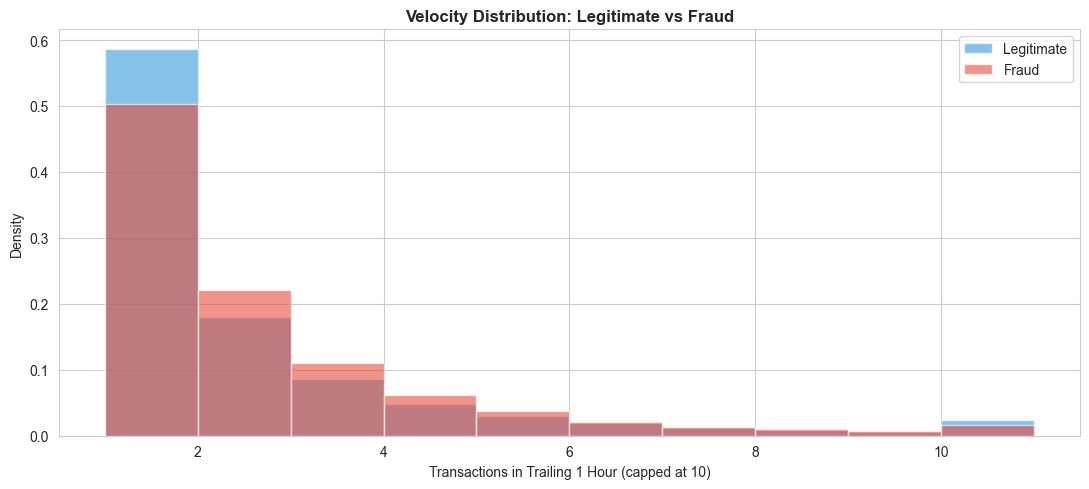

In [6]:
# Pull a sample of per-row velocity for the distribution shape
query_dist = """
SELECT 
    is_fraud,
    COUNT(*) OVER (
        PARTITION BY card_id 
        ORDER BY transaction_dt 
        RANGE BETWEEN INTERVAL '1 hour' PRECEDING AND CURRENT ROW
    ) AS txns_last_1h
FROM fraud_dw.fact_transactions
"""
df_dist = pd.read_sql(query_dist, engine)

fig, ax = plt.subplots(figsize=(11, 5))

# Cap at 10 for readable bins
df_dist['velocity_capped'] = df_dist['txns_last_1h'].clip(upper=10)

for fraud_flag, color, label in [(False, '#3498db', 'Legitimate'), 
                                  (True, '#e74c3c', 'Fraud')]:
    subset = df_dist[df_dist['is_fraud'] == fraud_flag]
    ax.hist(subset['velocity_capped'], bins=range(1, 12), alpha=0.6,
            color=color, label=label, density=True)

ax.set_xlabel('Transactions in Trailing 1 Hour (capped at 10)')
ax.set_ylabel('Density')
ax.set_title('Velocity Distribution: Legitimate vs Fraud',
             fontsize=12, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('visuals/phase3_q1_velocity_distribution.png', bbox_inches='tight')
plt.show()

In [7]:
## -- Q3 plot

query3 = """
with velocity as (
	select transaction_id,
			is_fraud,
			count(*) over (partition by card_id
					order by transaction_dt
					range between interval '1 hour' preceding and current row)
					as txns_last_1hr
	from fraud_dw.fact_transactions
)

select 
	case
		when txns_last_1hr = 1 then '1 txn'
		when txns_last_1hr = 2 then '2 txns'
		when txns_last_1hr = 3 then '3 txns'
		when txns_last_1hr between 4 and 5 then '4-5 txns'
		when txns_last_1hr between 6 and 10 then '6-10 txns'
		else '10+ txns'
	end 							as velocity_bucket,
	count(*)						as txn_count,
	count(*) filter(where is_fraud) as fraud_count,
	round(100 * count(*) filter(where is_fraud)
			/ count(*))				as fraud_rate_pct

from velocity
group by velocity_bucket
order by Min(txns_last_1hr);"""

df3 = pd.read_sql(query3,engine)
df3

,velocity_bucket,txn_count,fraud_count,fraud_rate_pct
0,1 txn,344778,10406,3.0
1,2 txns,107180,4565,4.0
2,3 txns,51237,2276,4.0
3,4-5 txns,46195,2040,4.0
4,6-10 txns,29403,1138,3.0
5,10+ txns,11747,238,2.0


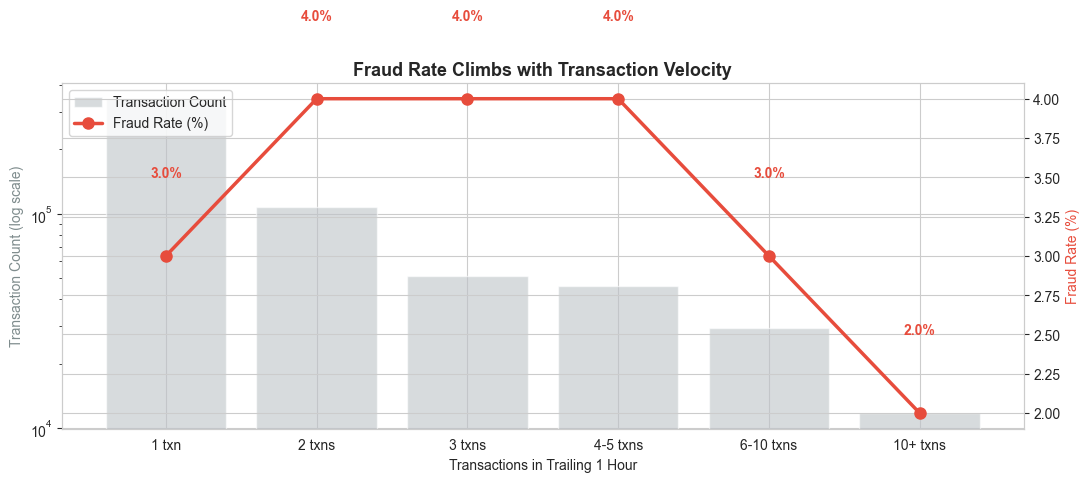

In [8]:
## -- Q3 plot

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

x = range(len(df3))

# Bars: transaction count (log scale, since high-velocity is rare)
ax1.bar(x, df3['txn_count'], color='#bdc3c7', alpha=0.6, label='Transaction Count')
ax1.set_yscale('log')
ax1.set_ylabel('Transaction Count (log scale)', color='#7f8c8d')
ax1.set_xticks(x)
ax1.set_xticklabels(df3['velocity_bucket'])
ax1.set_xlabel('Transactions in Trailing 1 Hour')

# Line: fraud rate (the story)
ax2.plot(x, df3['fraud_rate_pct'], color='#e74c3c', 
         marker='o', linewidth=2.5, markersize=8, label='Fraud Rate (%)')
ax2.set_ylabel('Fraud Rate (%)', color='#e74c3c')

ax1.set_title('Fraud Rate Climbs with Transaction Velocity',
              fontsize=13, fontweight='bold')

# Annotate fraud rate values
for xi, rate in zip(x, df3['fraud_rate_pct']):
    ax2.text(xi, rate + 0.5, f'{rate:.1f}%', ha='center', 
             color='#e74c3c', fontweight='bold')

l1, lab1 = ax1.get_legend_handles_labels()
l2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(l1 + l2, lab1 + lab2, loc='upper left')

plt.tight_layout()
plt.savefig('visuals/phase3_q3_velocity_fraud_rate.png', bbox_inches='tight')
plt.show()

In [12]:
## Query 4 -- Baseline count of transaction for per card

query4 = """
with velocity as (
	select transaction_id,
			card_id,
			transaction_dt,
			is_fraud,
			count(*) over (partition by card_id
					order by transaction_dt
					range between interval '1 hour' preceding and current row)
					as txns_last_1hr
	from fraud_dw.fact_transactions
),
card_baseline as (
	select card_id,
	-- chking 95% times the card txn count to comapre
			percentile_cont(0.95) within group
					(order by txns_last_1hr) as pct_95_velocity,
			avg(txns_last_1hr) as avg_velovity
	from velocity
	group by card_id
)
select 
	case
		when v.txns_last_1hr > cb.pct_95_velocity and pct_95_velocity >1
			then 'Above own pct_95'
			else 'Normal for cards'
			end 																as velocity_status,
	count(*)										as txn_count,
	count(*) filter (where is_fraud) 				as fraud_count,
	round(100 * count(*) filter(where is_fraud)
			/ count(*))								as fraud_rate_pct

from velocity v join card_baseline cb
using (card_id)
group by velocity_status
order by fraud_rate_pct desc;"""

df4 = pd.read_sql_query(text(query4), con=engine)
df4

,velocity_status,txn_count,fraud_count,fraud_rate_pct
0,Above own pct_95,20705,1087,5.0
1,Normal for cards,569835,19576,3.0


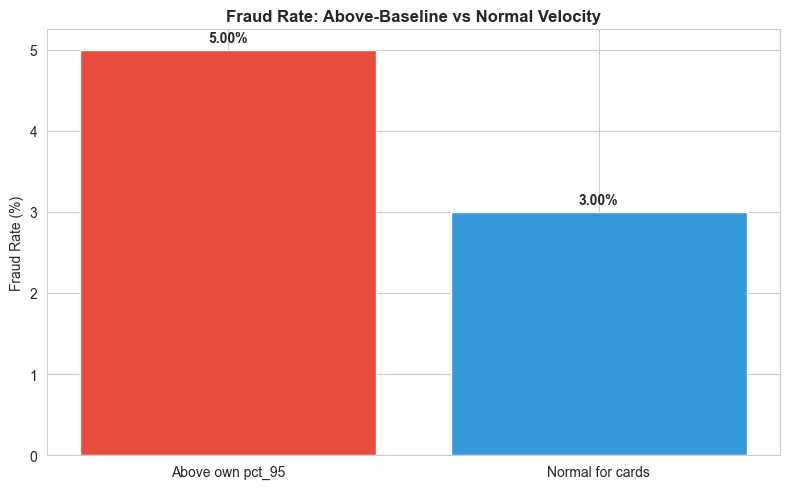

In [13]:
## Q4 plot

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(df4['velocity_status'], df4['fraud_rate_pct'],
              color=['#e74c3c', '#3498db'])
ax.set_ylabel('Fraud Rate (%)')
ax.set_title('Fraud Rate: Above-Baseline vs Normal Velocity',
             fontsize=12, fontweight='bold')

for bar, rate in zip(bars, df4['fraud_rate_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{rate:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('visuals/phase3_q4_baseline_deviation.png', bbox_inches='tight')
plt.show()

In [16]:
## Query 5 -- Top 20 cards with most movement

query5 = """
with velocity as (
	select
			transaction_id,
			card_id,
			transaction_dt,
			is_fraud,
			transaction_amt,

			count(*) over (partition by card_id
						order by transaction_dt
						range between interval '1 hour' preceding and current row)
						as txns_last_1hr,

			round(sum(transaction_amt) over (partition by card_id
						order by transaction_dt
						range between interval '1 hour' preceding and current row),2)
						as amt_last_1hr
from fraud_dw.fact_transactions
)
select 
		card_id,
		transaction_dt,
		txns_last_1hr,
		amt_last_1hr,
		is_fraud
from velocity
order by txns_last_1hr desc, amt_last_1hr desc
limit 20;"""

df5 = pd.read_sql(query5,engine)
df5.head()

,card_id,transaction_dt,txns_last_1hr,amt_last_1hr,is_fraud
0,1884,2018-05-22 01:00:14,192,17779.0,False
1,1884,2018-05-22 00:59:56,192,17717.0,False
2,1884,2018-05-22 00:59:15,192,17655.0,False
3,1884,2018-05-22 01:00:27,191,17735.0,False
4,1884,2018-05-22 01:00:08,191,17673.0,False


In [20]:
## Q5 plot

# Q5 is best shown as a clean table, not a chart
df5_display = df5.copy()
df5_display['is_fraud'] = df5_display['is_fraud'].map({True: '⚠️ Fraud', False: 'Legit'})
df5_display['amt_last_1hr'] = df5_display['amt_last_1hr'].apply(lambda x: f'${x:,.2f}')

df5_display.style.set_caption("Top 20 Highest-Velocity Card-Moments")

,card_id,transaction_dt,txns_last_1hr,amt_last_1hr,is_fraud
0,1884,2018-05-22 01:00:14,192,"$17,779.00",Legit
1,1884,2018-05-22 00:59:56,192,"$17,717.00",Legit
2,1884,2018-05-22 00:59:15,192,"$17,655.00",Legit
3,1884,2018-05-22 01:00:27,191,"$17,735.00",Legit
4,1884,2018-05-22 01:00:08,191,"$17,673.00",Legit
5,1884,2018-05-22 00:59:51,191,"$17,611.00",Legit
6,1884,2018-05-22 00:59:10,191,"$17,549.00",Legit
7,1884,2018-05-22 00:59:01,190,"$17,443.00",Legit
8,1884,2018-05-22 01:02:45,189,"$17,802.00",Legit
9,1884,2018-05-22 00:58:56,189,"$17,337.00",Legit


### Phase 3 Finding: Velocity is NOT a usable fraud signal in this dataset 

Contrary to the standard fraud-analytics expectation, transaction velocity 
(transactions per card per hour) showed no positive correlation with fraud. 
Fraud rate stayed near the 3.5% baseline across all velocity buckets, and the 
highest-velocity transactions were *less* likely to be fraudulent.

The root cause is the dataset's anonymization: `card_id` is derived from coded 
card attributes (card1–card6), so it represents a *cluster* of similar cards 
rather than an individual card. The highest-velocity card_ids are simply the 
most common, well-established card profiles — high legitimate volume, low fraud.
